<a href="https://colab.research.google.com/github/dacluan94066/THDeeplearning/blob/main/THDeepLearning_Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 THỰC HÀNH 4: CONVOLUTIONAL NEURAL NETWORK
### Bao gồm 4 bài tập:
- **Bài 1:** Nhận dạng ảnh CIFAR-10 (10 nhãn)
- **Bài 2:** Nhận dạng Cat vs Dog
- **Bài 3:** Nhận dạng Fashion-MNIST
- **Bài 4:** Nhận dạng khuôn mặt Nam/Nữ

> ⚡ Khuyến nghị: Vào **Runtime > Change runtime type > GPU** để huấn luyện nhanh hơn

---
## 📦 Cài đặt thư viện dùng chung

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
# 🟥 BÀI TẬP 1: Nhận dạng ảnh CIFAR-10
**10 nhãn:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

In [2]:
# ============================================================
# BÀI 1 - BƯỚC 1: Nạp dữ liệu CIFAR-10
# ============================================================
from tensorflow.keras.datasets import cifar10

CLASS_NAMES_CIFAR = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']

(X_train_c, y_train_c), (X_test_c, y_test_c) = cifar10.load_data()

# Chuẩn hóa về [0,1]
X_train_c = X_train_c.astype('float32') / 255.0
X_test_c  = X_test_c.astype('float32')  / 255.0

print('Train shape:', X_train_c.shape)   # (50000, 32, 32, 3)
print('Test  shape:', X_test_c.shape)    # (10000, 32, 32, 3)
print('Classes:', CLASS_NAMES_CIFAR)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train shape: (50000, 32, 32, 3)
Test  shape: (10000, 32, 32, 3)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


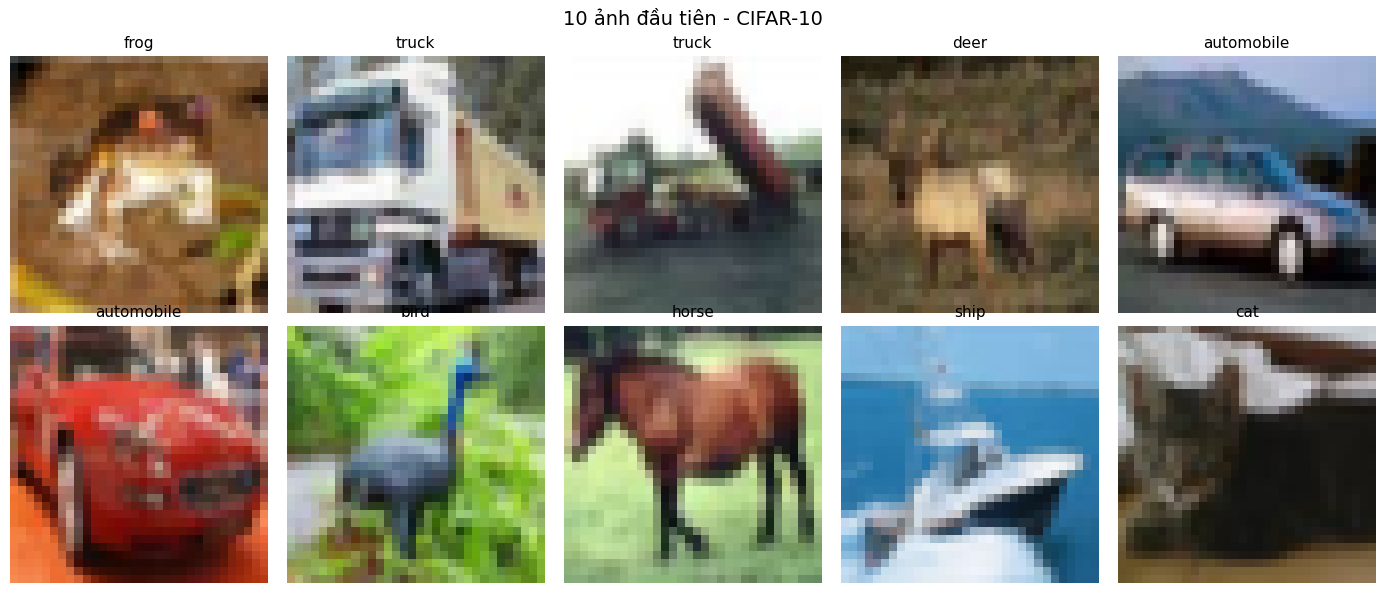

In [3]:
# ============================================================
# BÀI 1 - BƯỚC 2: Trực quan hóa dữ liệu
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_c[i])
    axes[i].set_title(CLASS_NAMES_CIFAR[y_train_c[i][0]], fontsize=11)
    axes[i].axis('off')
plt.suptitle('10 ảnh đầu tiên - CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# BÀI 1 - BƯỚC 3: Chuyển nhãn sang one-hot encoding
# ============================================================
num_classes = 10
y_train_c_oh = keras.utils.to_categorical(y_train_c, num_classes)
y_test_c_oh  = keras.utils.to_categorical(y_test_c,  num_classes)
print('y_train shape sau one-hot:', y_train_c_oh.shape)

y_train shape sau one-hot: (50000, 10)


In [5]:
# ============================================================
# BÀI 1 - BƯỚC 4: Xây dựng mô hình CNN cho CIFAR-10
# ============================================================
def build_cifar_model():
    model = Sequential([
        Input(shape=(32, 32, 3)),

        # Block 1
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.4),

        # Fully Connected
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

model_cifar = build_cifar_model()
model_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_cifar.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [6]:
# ============================================================
# BÀI 1 - BƯỚC 5: Huấn luyện mô hình
# ============================================================
callbacks_cifar = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Data augmentation giúp tăng độ chính xác
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train_c)

history_cifar = model_cifar.fit(
    datagen.flow(X_train_c, y_train_c_oh, batch_size=128),
    epochs=50,
    validation_data=(X_test_c, y_test_c_oh),
    callbacks=callbacks_cifar,
    verbose=1
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.3844 - loss: 1.8432 - val_accuracy: 0.2858 - val_loss: 2.4750 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.5301 - loss: 1.3048 - val_accuracy: 0.5690 - val_loss: 1.1807 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.5945 - loss: 1.1284 - val_accuracy: 0.6552 - val_loss: 0.9924 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.6384 - loss: 1.0177 - val_accuracy: 0.5988 - val_loss: 1.2178 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.6671 - loss: 0.9448 - val_accuracy: 0.6131 - val_loss: 1.1840 - learning_rate: 0.0010
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 82ms/step - accuracy: 0.6900 - loss: 0.8817 - val_accuracy: 0.6717 - val_loss: 0.9983 - learning_rate: 0.0010
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - accuracy: 0.7045 - 

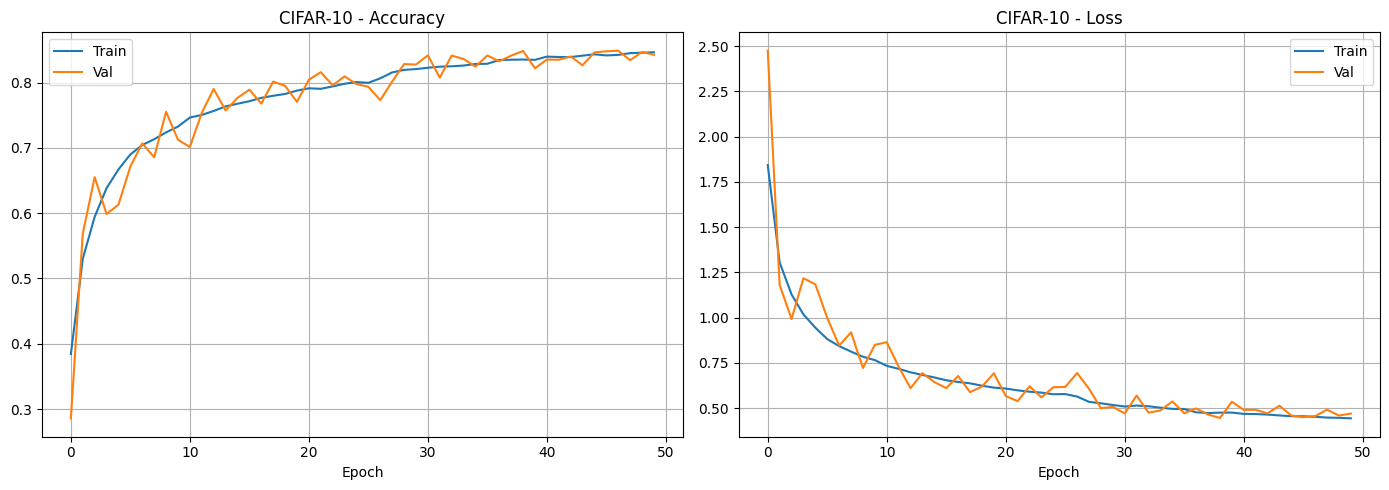


✅ CIFAR-10 Test Loss: 0.4561 | Test Accuracy: 84.89%


In [7]:
# ============================================================
# BÀI 1 - BƯỚC 6: Đánh giá & Trực quan hóa kết quả
# ============================================================
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'],   label='Train')
    ax1.plot(history.history['val_accuracy'],label='Val')
    ax1.set_title(f'{title} - Accuracy'); ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(True)

    ax2.plot(history.history['loss'],    label='Train')
    ax2.plot(history.history['val_loss'], label='Val')
    ax2.set_title(f'{title} - Loss'); ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()

plot_history(history_cifar, 'CIFAR-10')

loss_c, acc_c = model_cifar.evaluate(X_test_c, y_test_c_oh, verbose=0)
print(f'\n✅ CIFAR-10 Test Loss: {loss_c:.4f} | Test Accuracy: {acc_c*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

    airplane       0.88      0.87      0.88      1000
  automobile       0.93      0.96      0.94      1000
        bird       0.86      0.77      0.81      1000
         cat       0.80      0.64      0.71      1000
        deer       0.79      0.85      0.82      1000
         dog       0.89      0.68      0.77      1000
        frog       0.68      0.97      0.80      1000
       horse       0.91      0.88      0.90      1000
        ship       0.92      0.94      0.93      1000
       truck       0.89      0.93      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



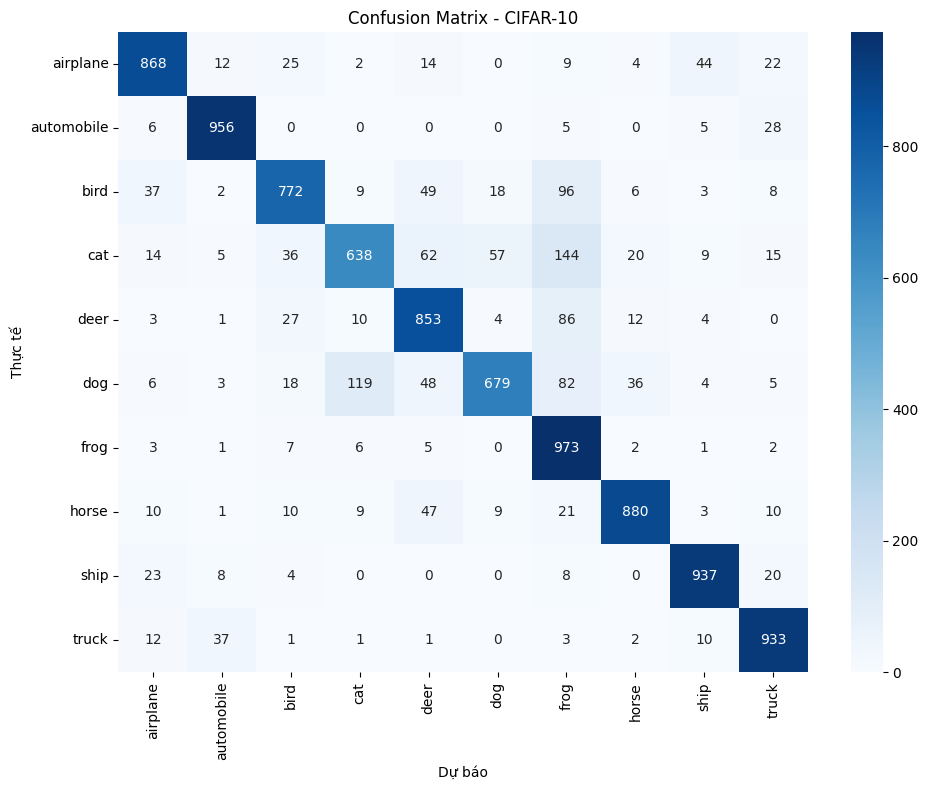

In [8]:
# ============================================================
# BÀI 1 - BƯỚC 7: Confusion Matrix & Classification Report
# ============================================================
y_pred_c = np.argmax(model_cifar.predict(X_test_c), axis=1)
y_true_c = y_test_c.flatten()

print(classification_report(y_true_c, y_pred_c, target_names=CLASS_NAMES_CIFAR))

cm = confusion_matrix(y_true_c, y_pred_c)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_CIFAR, yticklabels=CLASS_NAMES_CIFAR)
plt.title('Confusion Matrix - CIFAR-10')
plt.ylabel('Thực tế'); plt.xlabel('Dự báo')
plt.tight_layout(); plt.show()

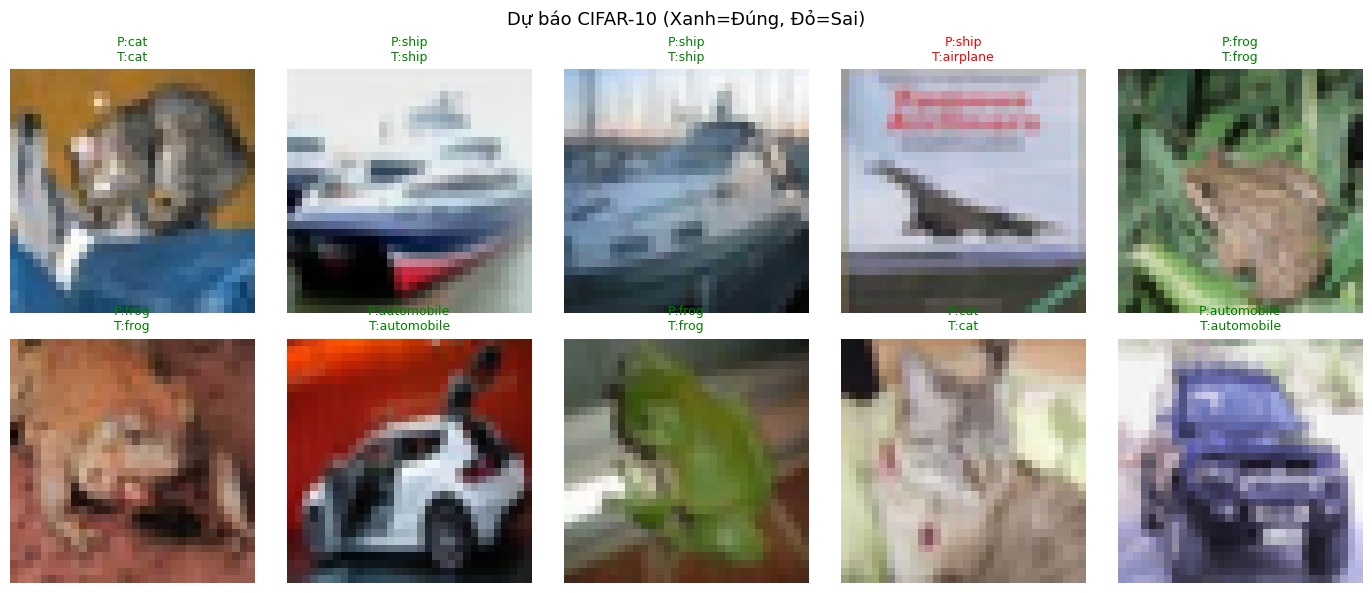

✅ Đã lưu trọng số: cifar10_cnn.weights.h5


In [9]:
# ============================================================
# BÀI 1 - BƯỚC 8: Dự báo một số ảnh từ tập test
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_test_c[i])
    pred  = CLASS_NAMES_CIFAR[y_pred_c[i]]
    true  = CLASS_NAMES_CIFAR[y_true_c[i]]
    color = 'green' if pred == true else 'red'
    axes[i].set_title(f'P:{pred}\nT:{true}', color=color, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Dự báo CIFAR-10 (Xanh=Đúng, Đỏ=Sai)', fontsize=13)
plt.tight_layout(); plt.show()

# Lưu mô hình
model_cifar.save_weights('cifar10_cnn.weights.h5')
print('✅ Đã lưu trọng số: cifar10_cnn.weights.h5')

---
# 🟧 BÀI TẬP 2: Nhận dạng Cat vs Dog
> 📌 Dữ liệu: Tải từ TensorFlow Datasets (hoặc thay bằng dữ liệu giảng viên cung cấp)

In [10]:
# ============================================================
# BÀI 2 - BƯỚC 1: Nạp dữ liệu Cat vs Dog
# ============================================================
# CÁCH 1: Dùng tensorflow_datasets (tự động tải)
# CÁCH 2: Upload dữ liệu từ máy tính (xem hướng dẫn bên dưới)

# --- CÁCH 1: TF Datasets ---
import tensorflow_datasets as tfds

IMG_SIZE_DOG = 64
BATCH_SIZE   = 32

def preprocess_catdog(image, label):
    image = tf.image.resize(image, [IMG_SIZE_DOG, IMG_SIZE_DOG])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

(ds_train_cd, ds_test_cd), info_cd = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

ds_train_cd = ds_train_cd.map(preprocess_catdog).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test_cd  = ds_test_cd.map(preprocess_catdog).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

CLASS_NAMES_CD = ['Cat', 'Dog']
print('Tổng số ảnh:', info_cd.splits['train'].num_examples)
print('Classes:', CLASS_NAMES_CD)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.4PT7UK_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Tổng số ảnh: 23262
Classes: ['Cat', 'Dog']


In [ ]:
# --- CÁCH 2: Upload dữ liệu giảng viên cung cấp ---
# Bỏ comment đoạn bên dưới nếu dùng dữ liệu giảng viên

# from google.colab import files
# uploaded = files.upload()   # Chọn file .zip dữ liệu
# import zipfile, os
# with zipfile.ZipFile(list(uploaded.keys())[0], 'r') as z:
#     z.extractall('/content/catdog')
#
# # Sau đó dùng ImageDataGenerator
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# datagen_cd = ImageDataGenerator(rescale=1./255, validation_split=0.2)
# ds_train_cd = datagen_cd.flow_from_directory(
#     '/content/catdog', target_size=(64,64), batch_size=32,
#     class_mode='binary', subset='training')
# ds_test_cd  = datagen_cd.flow_from_directory(
#     '/content/catdog', target_size=(64,64), batch_size=32,
#     class_mode='binary', subset='validation')

print('Hướng dẫn: Bỏ comment đoạn trên nếu dùng dữ liệu giảng viên')

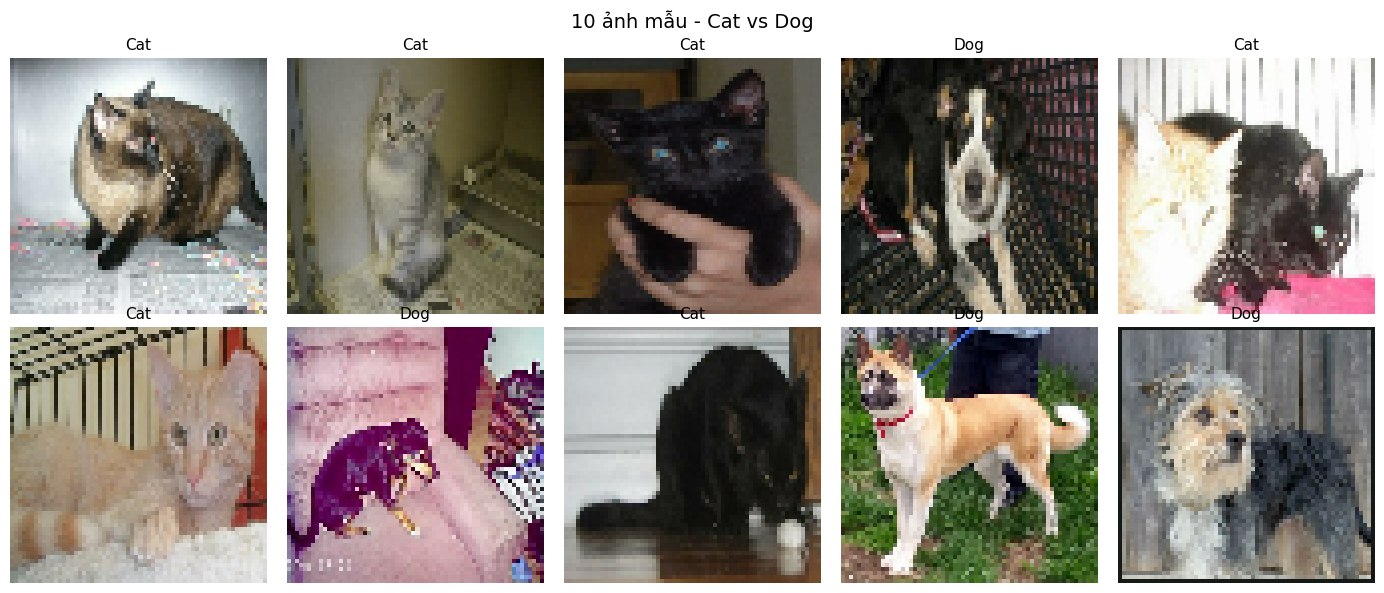

In [11]:
# ============================================================
# BÀI 2 - BƯỚC 2: Trực quan hóa
# ============================================================
sample_images, sample_labels = next(iter(ds_train_cd))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(sample_images[i].numpy())
    axes[i].set_title(CLASS_NAMES_CD[sample_labels[i].numpy()], fontsize=11)
    axes[i].axis('off')
plt.suptitle('10 ảnh mẫu - Cat vs Dog', fontsize=14)
plt.tight_layout(); plt.show()

In [13]:
# ============================================================
# BÀI 2 - BƯỚC 3: Xây dựng CNN cho Cat vs Dog
# ============================================================
def build_catdog_model():
    model = Sequential([
        Input(shape=(IMG_SIZE_DOG, IMG_SIZE_DOG, 3)),

        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.4),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')   # Binary: Cat=0, Dog=1
    ])
    return model

model_cd = build_catdog_model()
model_cd.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_cd.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,191,809 (8.36 MB)

 Trainable params: 2,191,361 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
# ============================================================
# BÀI 2 - BƯỚC 4: Huấn luyện
# ============================================================
callbacks_cd = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=4, verbose=1)
]

history_cd = model_cd.fit(
    ds_train_cd,
    epochs=30,
    validation_data=ds_test_cd,
    callbacks=callbacks_cd,
    verbose=1
)

Epoch 1/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.6515 - loss: 0.7044 - val_accuracy: 0.5555 - val_loss: 0.6995 - learning_rate: 0.0010
Epoch 2/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.7159 - loss: 0.5617 - val_accuracy: 0.7466 - val_loss: 0.5100 - learning_rate: 0.0010
Epoch 3/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.7528 - loss: 0.5055 - val_accuracy: 0.7945 - val_loss: 0.4568 - learning_rate: 0.0010
Epoch 4/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.7850 - loss: 0.4604 - val_accuracy: 0.6219 - val_loss: 0.7583 - learning_rate: 0.0010
Epoch 5/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.8023 - loss: 0.4281 - val_accuracy: 0.7741 - val_loss: 0.4953 - learning_rate: 0.0010
Epoch 6/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.8221 - loss: 0.4022 - val_accuracy: 0.8190 - val_loss: 0.4014 - learning_rate: 0.0010
Epoch 7/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.8345 - l

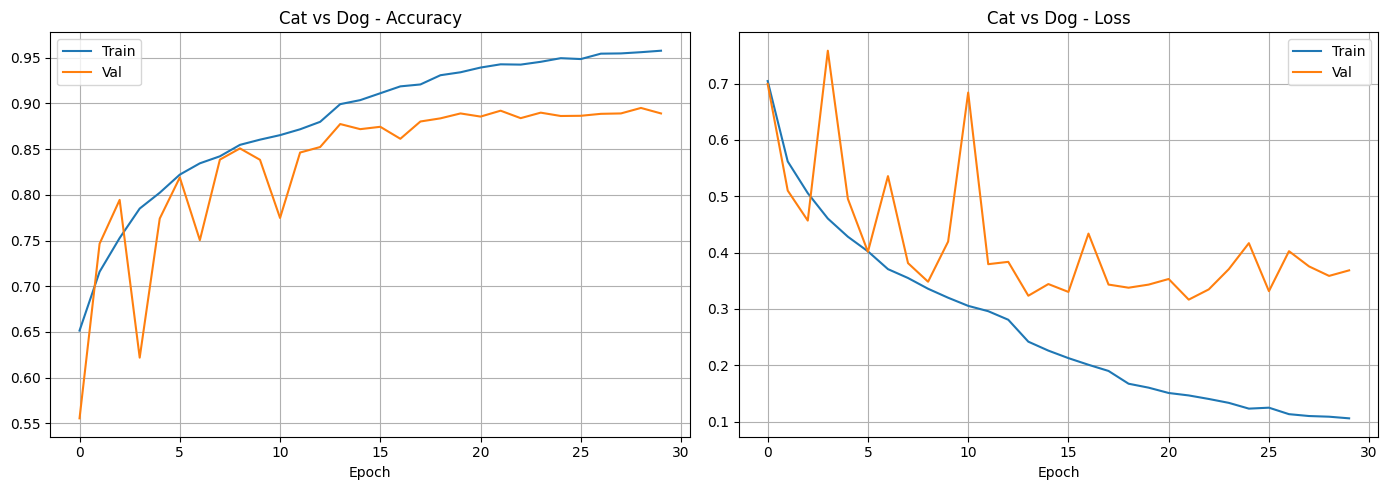


✅ Cat vs Dog Test Loss: 0.3586 | Test Accuracy: 89.51%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step


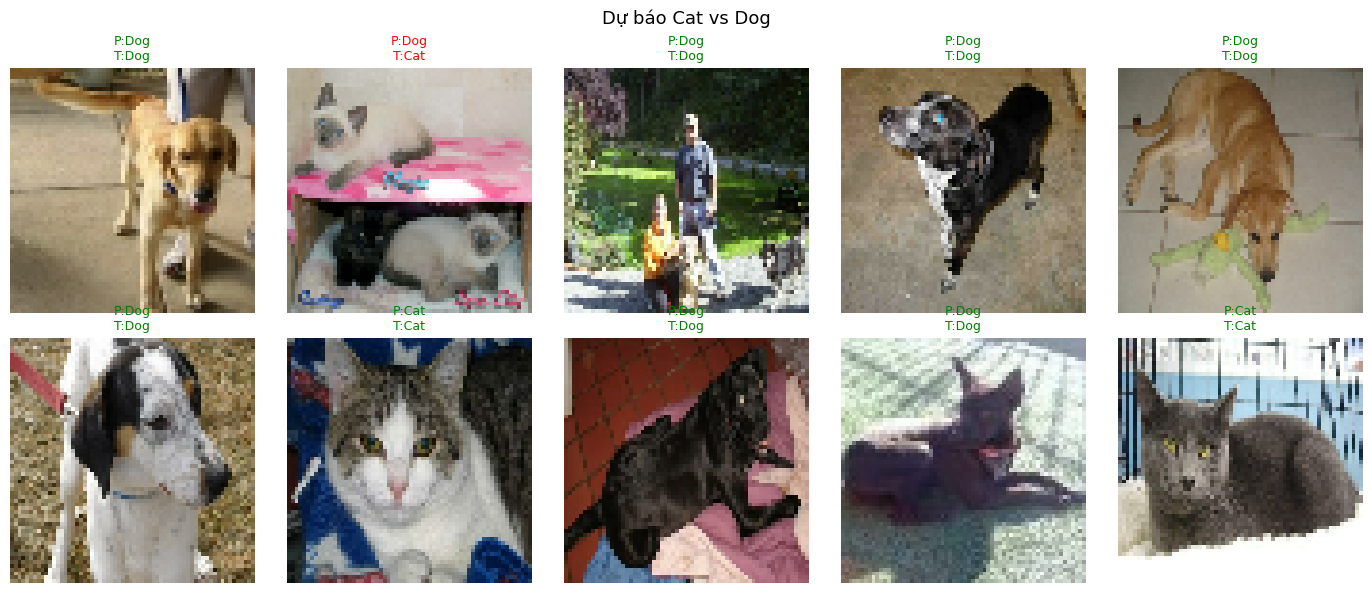

✅ Đã lưu trọng số: catdog_cnn.weights.h5


In [15]:
# ============================================================
# BÀI 2 - BƯỚC 5: Đánh giá & Lưu mô hình
# ============================================================
plot_history(history_cd, 'Cat vs Dog')

loss_cd, acc_cd = model_cd.evaluate(ds_test_cd, verbose=0)
print(f'\n✅ Cat vs Dog Test Loss: {loss_cd:.4f} | Test Accuracy: {acc_cd*100:.2f}%')

# Dự báo & hiển thị
sample_imgs, sample_lbls = next(iter(ds_test_cd))
preds = (model_cd.predict(sample_imgs) > 0.5).astype(int).flatten()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(sample_imgs[i].numpy())
    pred  = CLASS_NAMES_CD[preds[i]]
    true  = CLASS_NAMES_CD[sample_lbls[i].numpy()]
    color = 'green' if pred == true else 'red'
    axes[i].set_title(f'P:{pred}\nT:{true}', color=color, fontsize=9)
    axes[i].axis('off')
plt.suptitle('Dự báo Cat vs Dog', fontsize=13)
plt.tight_layout(); plt.show()

model_cd.save_weights('catdog_cnn.weights.h5')
print('✅ Đã lưu trọng số: catdog_cnn.weights.h5')

---
# 🟨 BÀI TẬP 3: Nhận dạng Fashion-MNIST
**10 nhãn:** T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot

In [16]:
# ============================================================
# BÀI 3 - BƯỚC 1: Nạp dữ liệu Fashion-MNIST
# ============================================================
from tensorflow.keras.datasets import fashion_mnist

CLASS_NAMES_FM = ['T-shirt','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']

(X_train_fm, y_train_fm), (X_test_fm, y_test_fm) = fashion_mnist.load_data()

# Reshape thêm chiều channel + chuẩn hóa
X_train_fm = X_train_fm.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_fm  = X_test_fm.reshape(-1, 28, 28, 1).astype('float32')  / 255.0

y_train_fm_oh = keras.utils.to_categorical(y_train_fm, 10)
y_test_fm_oh  = keras.utils.to_categorical(y_test_fm,  10)

print('Train:', X_train_fm.shape, '| Test:', X_test_fm.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)


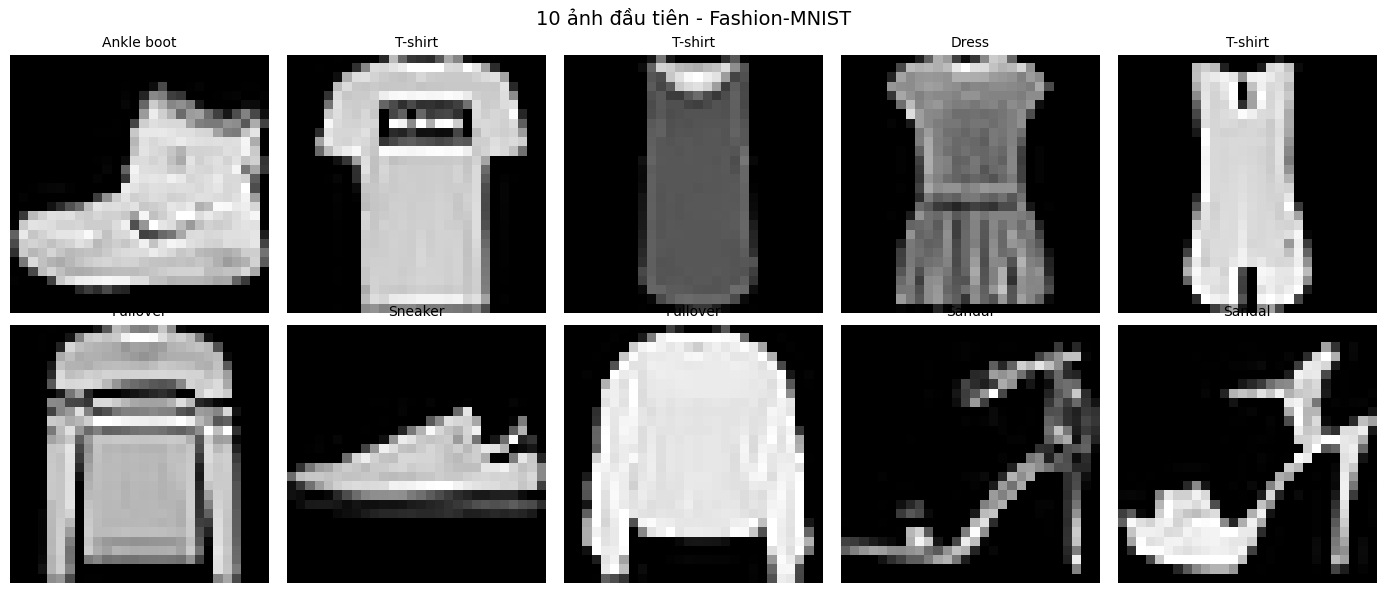

In [17]:
# ============================================================
# BÀI 3 - BƯỚC 2: Trực quan hóa
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_fm[i].reshape(28,28), cmap='gray')
    axes[i].set_title(CLASS_NAMES_FM[y_train_fm[i]], fontsize=10)
    axes[i].axis('off')
plt.suptitle('10 ảnh đầu tiên - Fashion-MNIST', fontsize=14)
plt.tight_layout(); plt.show()

In [18]:
# ============================================================
# BÀI 3 - BƯỚC 3: Xây dựng CNN cho Fashion-MNIST
# ============================================================
def build_fashion_model():
    model = Sequential([
        Input(shape=(28, 28, 1)),

        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.4),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

model_fm = build_fashion_model()
model_fm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_fm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)

In [19]:
# ============================================================
# BÀI 3 - BƯỚC 4: Huấn luyện
# ============================================================
callbacks_fm = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=1)
]

datagen_fm = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

history_fm = model_fm.fit(
    datagen_fm.flow(X_train_fm, y_train_fm_oh, batch_size=128),
    epochs=30,
    validation_data=(X_test_fm, y_test_fm_oh),
    callbacks=callbacks_fm,
    verbose=1
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.7428 - loss: 0.7197 - val_accuracy: 0.7166 - val_loss: 0.7233 - learning_rate: 0.0010
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.8247 - loss: 0.4757 - val_accuracy: 0.8513 - val_loss: 0.3902 - learning_rate: 0.0010
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8443 - loss: 0.4214 - val_accuracy: 0.8728 - val_loss: 0.3435 - learning_rate: 0.0010
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8594 - loss: 0.3864 - val_accuracy: 0.8826 - val_loss: 0.3265 - learning_rate: 0.0010
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.8664 - loss: 0.3682 - val_accuracy: 0.8903 - val_loss: 0.3039 - learning_rate: 0.0010
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8722 - loss: 0.3477 - val_accuracy: 0.8786 - val_loss: 0.3388 - learning_rate: 0.0010
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8769 - l

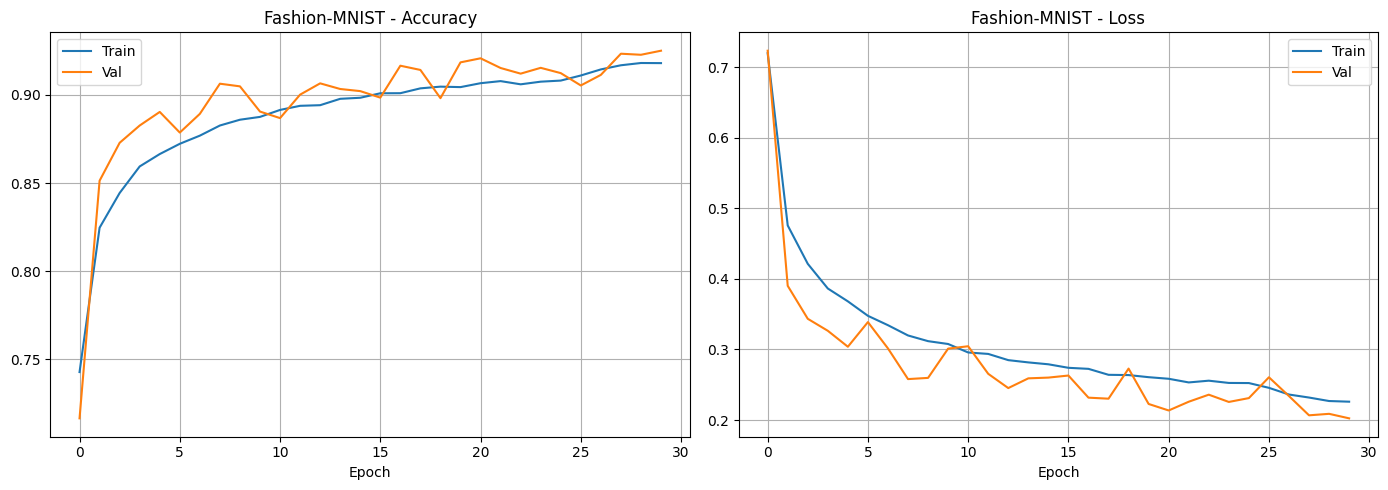


✅ Fashion-MNIST Test Loss: 0.2024 | Test Accuracy: 92.50%
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

     T-shirt       0.90      0.85      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.91      0.87      0.89      1000
       Dress       0.90      0.95      0.93      1000
        Coat       0.89      0.86      0.88      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.75      0.81      0.78      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.92      0.93     10000
weighted avg       0.93      0.93      0.93     10000



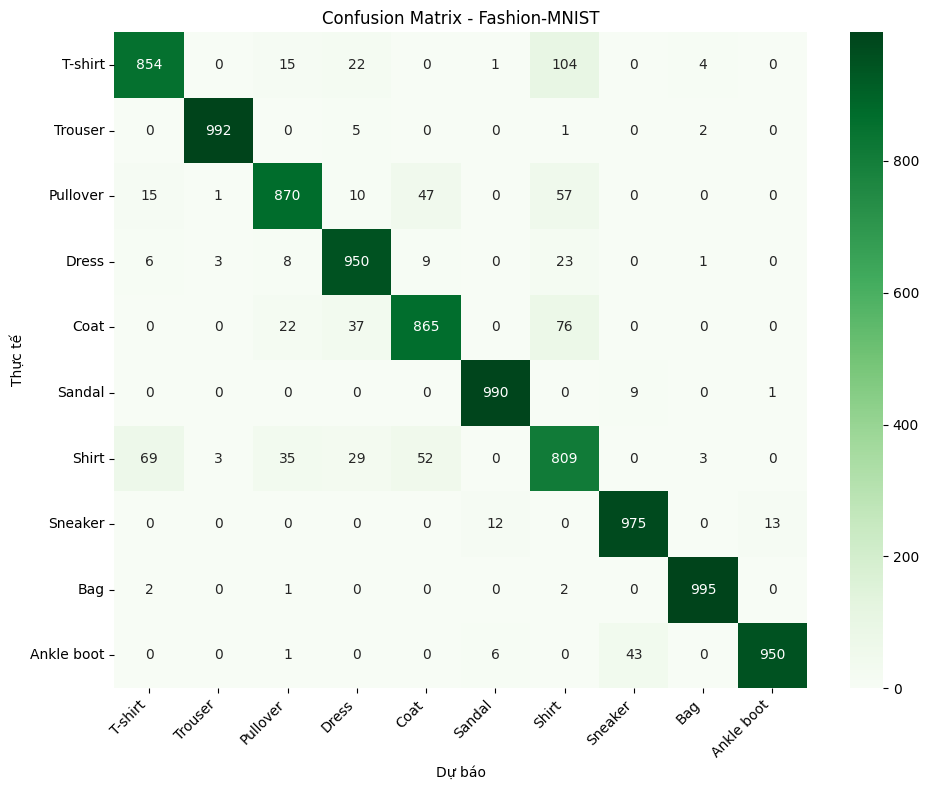

✅ Đã lưu trọng số: fashion_mnist_cnn.weights.h5


In [20]:
# ============================================================
# BÀI 3 - BƯỚC 5: Đánh giá & Lưu
# ============================================================
plot_history(history_fm, 'Fashion-MNIST')

loss_fm, acc_fm = model_fm.evaluate(X_test_fm, y_test_fm_oh, verbose=0)
print(f'\n✅ Fashion-MNIST Test Loss: {loss_fm:.4f} | Test Accuracy: {acc_fm*100:.2f}%')

y_pred_fm = np.argmax(model_fm.predict(X_test_fm), axis=1)
print(classification_report(y_test_fm, y_pred_fm, target_names=CLASS_NAMES_FM))

# Confusion matrix
cm_fm = confusion_matrix(y_test_fm, y_pred_fm)
plt.figure(figsize=(10,8))
sns.heatmap(cm_fm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES_FM, yticklabels=CLASS_NAMES_FM)
plt.title('Confusion Matrix - Fashion-MNIST')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.ylabel('Thực tế'); plt.xlabel('Dự báo')
plt.tight_layout(); plt.show()

model_fm.save_weights('fashion_mnist_cnn.weights.h5')
print('✅ Đã lưu trọng số: fashion_mnist_cnn.weights.h5')

---
# 🟩 BÀI TẬP 4: Nhận dạng khuôn mặt Nam / Nữ
> 📌 Dữ liệu: Tải từ CelebA (hoặc thay bằng dữ liệu giảng viên cung cấp)

In [21]:
# ============================================================
# BÀI 4 - BƯỚC 1: Nạp dữ liệu Nam/Nữ
# ============================================================
# CÁCH 1: Dùng CelebA từ TF Datasets (nhãn 'Male')
# CÁCH 2: Upload dữ liệu giảng viên (xem comment bên dưới)

IMG_SIZE_FACE = 64

# --- CÁCH 1: CelebA ---
def preprocess_celeba(features):
    image = tf.image.resize(features['image'], [IMG_SIZE_FACE, IMG_SIZE_FACE])
    image = tf.cast(image, tf.float32) / 255.0
    label = features['attributes']['Male']
    label = tf.cast(label, tf.int32)
    return image, label

(ds_train_face, ds_test_face), info_face = tfds.load(
    'celeb_a',
    split=['train', 'test'],
    with_info=True
)

ds_train_face = (ds_train_face
    .map(preprocess_celeba, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(2000).batch(64).prefetch(tf.data.AUTOTUNE))
ds_test_face  = (ds_test_face
    .map(preprocess_celeba, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64).prefetch(tf.data.AUTOTUNE))

CLASS_NAMES_FACE = ['Nữ (Female)', 'Nam (Male)']
print('Dataset CelebA đã sẵn sàng!')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.KC25B5_2.1.0/celeb_a-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.KC25B5_2.1.0/celeb_a-validation.tfrecord-[0-9][0-9][0-9…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/celeb_a/incomplete.KC25B5_2.1.0/celeb_a-test.tfrecord-[0-9][0-9][0-9][0-9]…

Dataset celeb_a downloaded and prepared to /root/tensorflow_datasets/celeb_a/2.1.0. Subsequent calls will reuse this data.
Dataset CelebA đã sẵn sàng!


In [ ]:
# --- CÁCH 2: Upload dữ liệu giảng viên ---
# Bỏ comment đoạn bên dưới nếu dùng dữ liệu giảng viên
# Cấu trúc thư mục mong đợi:
#   /content/face/
#       Nam/  (ảnh khuôn mặt nam)
#       Nu/   (ảnh khuôn mặt nữ)

# from google.colab import files
# uploaded = files.upload()
# import zipfile
# with zipfile.ZipFile(list(uploaded.keys())[0], 'r') as z:
#     z.extractall('/content/face')
#
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# datagen_face = ImageDataGenerator(rescale=1./255, validation_split=0.2,
#                                   horizontal_flip=True)
# ds_train_face = datagen_face.flow_from_directory(
#     '/content/face', target_size=(64,64), batch_size=32,
#     class_mode='binary', subset='training')
# ds_test_face  = datagen_face.flow_from_directory(
#     '/content/face', target_size=(64,64), batch_size=32,
#     class_mode='binary', subset='validation')
# CLASS_NAMES_FACE = list(ds_train_face.class_indices.keys())
# print('Classes:', CLASS_NAMES_FACE)

print('Hướng dẫn: Bỏ comment đoạn trên nếu dùng dữ liệu giảng viên')

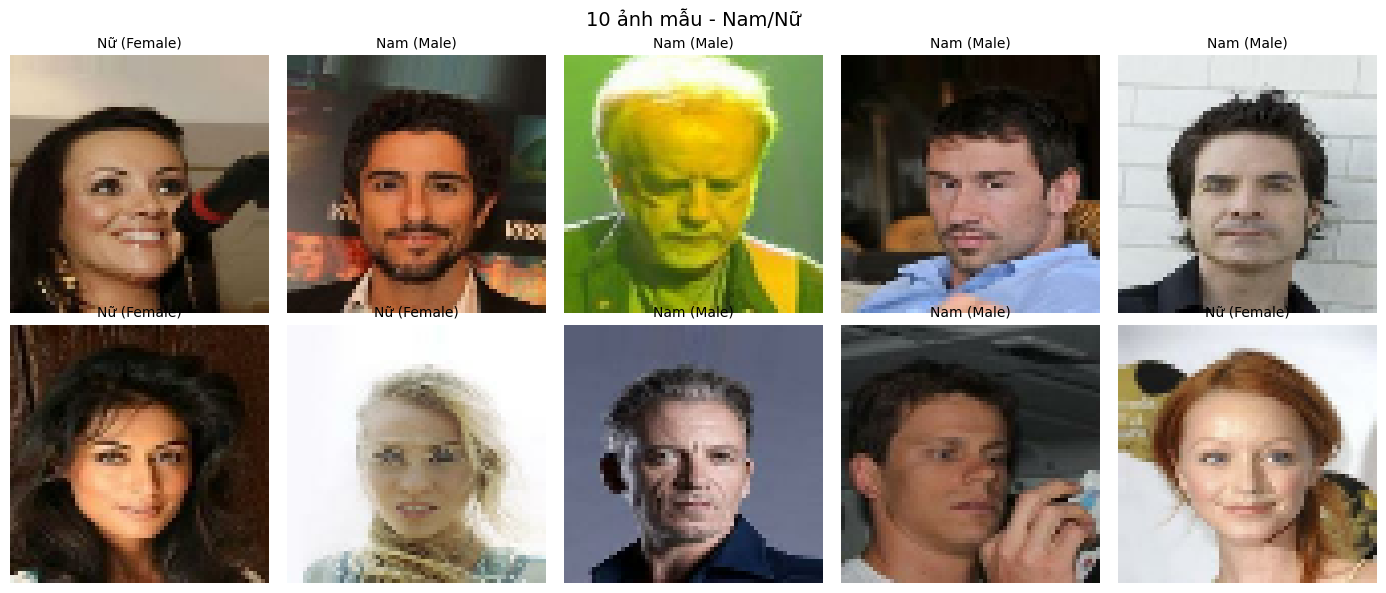

In [22]:
# ============================================================
# BÀI 4 - BƯỚC 2: Trực quan hóa
# ============================================================
sample_face, sample_face_lbl = next(iter(ds_train_face))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(sample_face[i].numpy())
    axes[i].set_title(CLASS_NAMES_FACE[sample_face_lbl[i].numpy()], fontsize=10)
    axes[i].axis('off')
plt.suptitle('10 ảnh mẫu - Nam/Nữ', fontsize=14)
plt.tight_layout(); plt.show()

In [23]:
# ============================================================
# BÀI 4 - BƯỚC 3: Xây dựng CNN cho Nam/Nữ
# ============================================================
def build_face_model():
    model = Sequential([
        Input(shape=(IMG_SIZE_FACE, IMG_SIZE_FACE, 3)),

        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.4),

        Conv2D(256, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.4),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')   # Binary: 0=Nữ, 1=Nam
    ])
    return model

model_face = build_face_model()
model_face.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_face.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,488,513 (9.49 MB)

 Trainable params: 2,487,553 (9.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
# ============================================================
# BÀI 4 - BƯỚC 4: Huấn luyện
# ============================================================
callbacks_face = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=4, verbose=1)
]

history_face = model_face.fit(
    ds_train_face,
    epochs=30,
    validation_data=ds_test_face,
    callbacks=callbacks_face,
    verbose=1
)

Epoch 1/30
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 110s 38ms/step - accuracy: 0.9016 - loss: 0.2492 - val_accuracy: 0.9505 - val_loss: 0.1227 - learning_rate: 0.0010
Epoch 2/30
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 90s 35ms/step - accuracy: 0.9515 - loss: 0.1278 - val_accuracy: 0.9619 - val_loss: 0.1000 - learning_rate: 0.0010
Epoch 3/30
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 89s 34ms/step - accuracy: 0.9581 - loss: 0.1114 - val_accuracy: 0.9542 - val_loss: 0.1258 - learning_rate: 0.0010
Epoch 4/30
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 143s 35ms/step - accuracy: 0.9619 - loss: 0.1021 - val_accuracy: 0.9680 - val_loss: 0.0822 - learning_rate: 0.0010
Epoch 5/30
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 148s 37ms/step - accuracy: 0.9647 - loss: 0.0957 - val_accuracy: 0.9707 - val_loss: 0.0766 - learning_rate: 0.0010
Epoch 6/30
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 92s 36ms/step - accuracy: 0.9666 - loss: 0.0912 - val_accuracy: 0.9696 - val_loss: 0.0784 - learning_rate: 0.0010
Epoch 7/30
2544/2544 ━━━━━━━━━━━━━━━━━━━━ 92s 36ms/step - acc

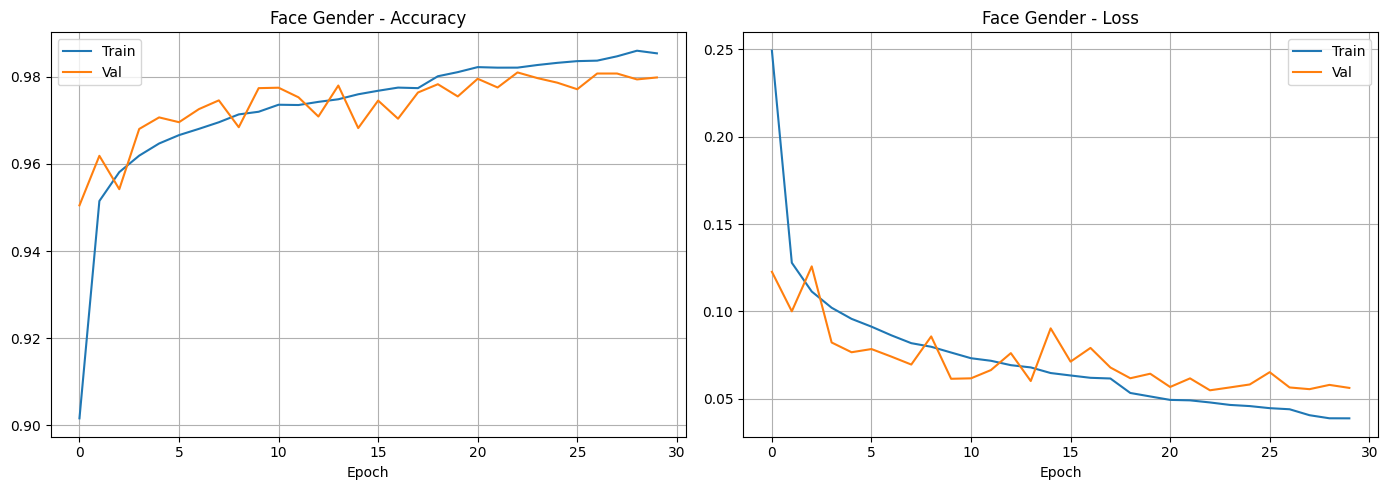


✅ Face Gender Test Loss: 0.0548 | Test Accuracy: 98.10%
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step 


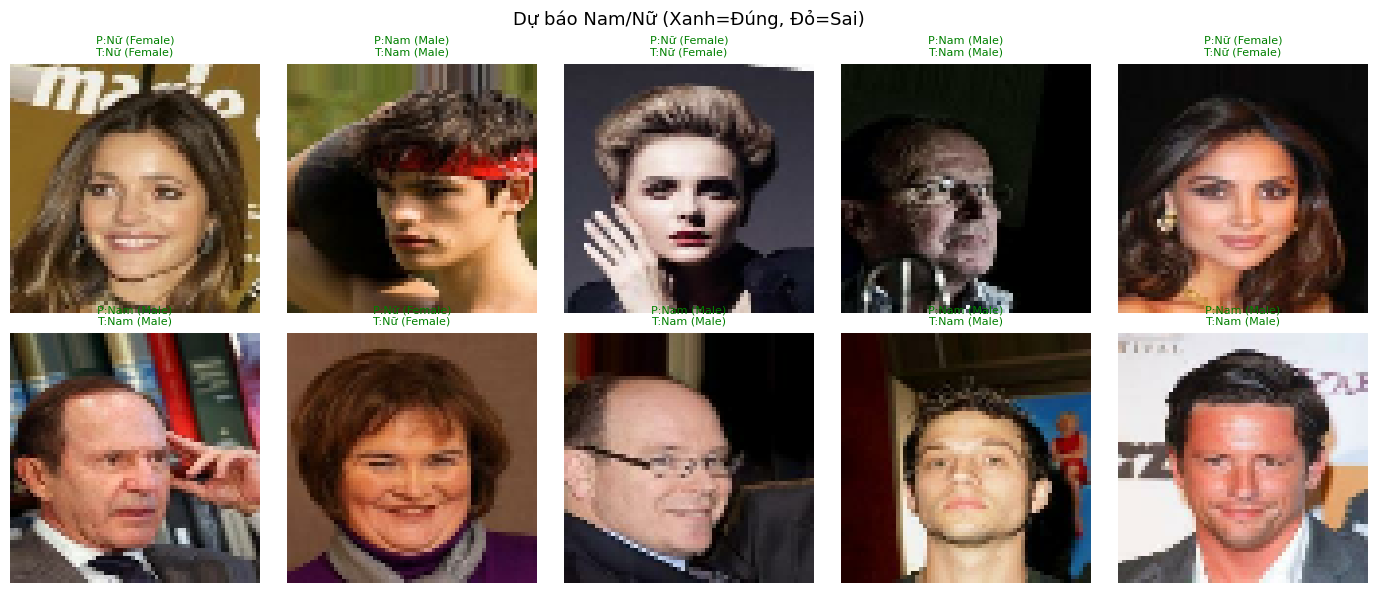

✅ Đã lưu trọng số: face_gender_cnn.weights.h5


In [25]:
# ============================================================
# BÀI 4 - BƯỚC 5: Đánh giá & Lưu
# ============================================================
plot_history(history_face, 'Face Gender')

loss_f, acc_f = model_face.evaluate(ds_test_face, verbose=0)
print(f'\n✅ Face Gender Test Loss: {loss_f:.4f} | Test Accuracy: {acc_f*100:.2f}%')

# Dự báo & hiển thị
sample_f, sample_fl = next(iter(ds_test_face))
preds_f = (model_face.predict(sample_f) > 0.5).astype(int).flatten()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(sample_f[i].numpy())
    pred_lbl = CLASS_NAMES_FACE[preds_f[i]]
    true_lbl = CLASS_NAMES_FACE[sample_fl[i].numpy()]
    color = 'green' if pred_lbl == true_lbl else 'red'
    axes[i].set_title(f'P:{pred_lbl}\nT:{true_lbl}', color=color, fontsize=8)
    axes[i].axis('off')
plt.suptitle('Dự báo Nam/Nữ (Xanh=Đúng, Đỏ=Sai)', fontsize=13)
plt.tight_layout(); plt.show()

model_face.save_weights('face_gender_cnn.weights.h5')
print('✅ Đã lưu trọng số: face_gender_cnn.weights.h5')


========== KẾT QUẢ 4 BÀI TẬP CNN ==========
             Bài tập  Test Accuracy (%)  Test Loss
     Bài 1: CIFAR-10              84.89     0.4561
   Bài 2: Cat vs Dog              89.51     0.3586
Bài 3: Fashion-MNIST              92.50     0.2024
       Bài 4: Nam/Nữ              98.10     0.0548


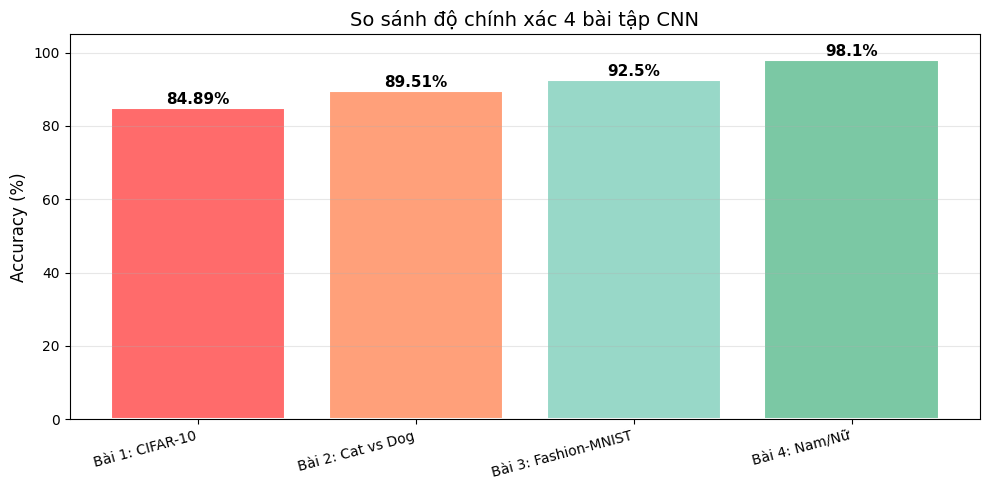

In [26]:
# ============================================================
# TỔNG KẾT - So sánh kết quả 4 bài
# ============================================================
import pandas as pd

results = {
    'Bài tập': ['Bài 1: CIFAR-10', 'Bài 2: Cat vs Dog', 'Bài 3: Fashion-MNIST', 'Bài 4: Nam/Nữ'],
    'Test Accuracy (%)': [
        round(acc_c  * 100, 2),
        round(acc_cd * 100, 2),
        round(acc_fm * 100, 2),
        round(acc_f  * 100, 2)
    ],
    'Test Loss': [
        round(loss_c,  4),
        round(loss_cd, 4),
        round(loss_fm, 4),
        round(loss_f,  4)
    ]
}

df_results = pd.DataFrame(results)
print('\n========== KẾT QUẢ 4 BÀI TẬP CNN ==========')
print(df_results.to_string(index=False))

# Biểu đồ so sánh
plt.figure(figsize=(10, 5))
bars = plt.bar(df_results['Bài tập'], df_results['Test Accuracy (%)'],
               color=['#FF6B6B','#FFA07A','#98D8C8','#7BC8A4'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, df_results['Test Accuracy (%)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('So sánh độ chính xác 4 bài tập CNN', fontsize=14)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()